# Wildlife Biodiversity Analysis using Camera Trap Data

## Project Overview

This project explores biodiversity patterns in tropical forests using camera trap data. 
The dataset contains species observations from multiple countries, including taxonomic classification 
and detection counts.

The primary goal is to investigate how animal groups (taxonomic orders) are distributed geographically 
and to examine potential relationships between animal types and location.

---

## Dataset

The dataset is publicly available from the CamTrapAsia initiative:  
[CamTrapAsia Biodiversity Dataset](https://zenodo.org/records/10780971)

Key fields include:

- `survey_id` : Unique survey identifier  
- `records` : Number of independent detections  
- `dataset` : Subset identifier  
- `Y_lat`, `X_long` : Latitude and longitude of survey location  
- `year_start` : Survey start year  
- `country` : Country of survey  
- `domestic` : Wild or domestic species  
- Taxonomic information: `class`, `order`, `family`, `genus`, `species`, `binomial_verified`  
- `taxonomic_level` : Most specific identified taxonomic level  

---

## Project Objectives

1. Load and clean the dataset for analysis.  
2. Explore biodiversity distribution using exploratory data analysis (EDA).  
3. Conduct statistical analysis to assess relationships between animal groups and countries.  
4. Visualize key patterns through charts and plots.

## Dataset Import & Initial Cleanup

In this section, we load the camera-trap biodiversity dataset into a pandas DataFrame, 
assign proper column names, and perform initial inspection of the dataset to understand 
its structure and contents.

## Data Cleaning and Preprocessing

Before analysis, we clean and prepare the dataset to ensure consistency:

- Remove rows with missing essential values (`survey_id`, `records`, `year_start`, `country`)  
- Convert numeric columns to appropriate data types  
- Remove any rows with invalid numeric values after conversion  
- Reset the index to maintain a clean DataFrame structure

In [2]:
import pandas as pd

columns = [
    "survey_id", "records", "dataset", "Y_lat", "X_long", "year_start",
    "country", "domestic", "uri", "class", "order", "family",
    "genus", "species", "binomial_verified", "taxonomic_level"
]

# Load dataset
df = pd.read_csv("camtrapasia_data.csv", header=None, names=columns)

# Now df exists, you can clean it
df = df.dropna(subset=['survey_id', 'records', 'year_start', 'country'])
df['records'] = pd.to_numeric(df['records'], errors='coerce')
df['year_start'] = pd.to_numeric(df['year_start'], errors='coerce')
df = df.dropna(subset=['records', 'year_start'])
df = df.reset_index(drop=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4554 entries, 0 to 4553
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   survey_id          4554 non-null   object 
 1   records            4554 non-null   int64  
 2   dataset            4554 non-null   object 
 3   Y_lat              4554 non-null   float64
 4   X_long             4554 non-null   float64
 5   year_start         4554 non-null   int64  
 6   country            4554 non-null   object 
 7   domestic           4554 non-null   object 
 8   uri                4554 non-null   object 
 9   class              4554 non-null   object 
 10  order              4554 non-null   object 
 11  family             4458 non-null   object 
 12  genus              4310 non-null   object 
 13  species            3990 non-null   object 
 14  binomial_verified  4554 non-null   object 
 15  taxonomic_level    4554 non-null   object 
dtypes: float64(2), int64(2),

## Preliminary Biodiversity Exploration

This section explores biodiversity patterns of wild animals across different countries.

The analysis focuses on:

1. Filtering the dataset to include only wild species.  
2. Examining how taxonomic orders are distributed across countries.  
3. Testing whether the distribution of animal orders is independent of country using a Chi-square test.  
4. Visualizing the top 5 most frequently recorded orders in each country using bar charts.  

,survey_id,records,dataset,Y_lat,X_long,year_start,country,domestic,uri,class,order,family,genus,species,binomial_verified,taxonomic_level
0,137.SEA,30,SEA,-2.264451,101.794251,2014,Indonesia,wild,https://www.ncbi.nlm.nih.gov/taxonomy/74864,Mammalia,Carnivora,Mustelidae,Martes,flavigula,Martes flavigula,species
1,138.SEA,21,SEA,-2.031408,101.126884,2015,Indonesia,wild,https://www.ncbi.nlm.nih.gov/taxonomy/74864,Mammalia,Carnivora,Mustelidae,Martes,flavigula,Martes flavigula,species
2,139.SEA,10,SEA,-3.024615,101.950937,2015,Indonesia,wild,https://www.ncbi.nlm.nih.gov/taxonomy/74864,Mammalia,Carnivora,Mustelidae,Martes,flavigula,Martes flavigula,species
3,135.SEA,5,SEA,3.717770,102.128800,2013,Malaysia,wild,https://www.ncbi.nlm.nih.gov/taxonomy/452597,Mammalia,Carnivora,Mustelidae,Aonyx,cinereus,Aonyx cinereus,species
4,120.SEA,6,SEA,-0.921494,102.385766,2005,Indonesia,wild,https://www.ncbi.nlm.nih.gov/taxonomy/452597,Mammalia,Carnivora,Mustelidae,Aonyx,cinereus,Aonyx cinereus,species


order,Accipitriformes,Anseriformes,Artiodactyla,Bucerotiformes,Caprimulgiformes,Carnivora,Casuariiformes,Chiroptera,Ciconiiformes,Columbiformes,...,Peramelemorphia,Perissodactyla,Pholidota,Piciformes,Primates,Proboscidea,Rodentia,Scandentia,Squamata,Strigiformes
country,,,,,,,,,,,,,,,,,,,,,
Bhutan,0,0,0,0,0,4,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Cambodia,0,1,60,0,0,117,0,0,1,0,...,0,0,2,0,18,7,19,0,0,0
India,0,0,10,0,0,23,0,0,0,0,...,0,0,0,0,3,0,6,0,0,0
Indonesia,4,0,243,5,0,426,2,4,1,11,...,2,36,22,0,160,15,106,14,23,0
Laos,0,0,72,0,0,149,0,0,0,1,...,0,0,5,0,58,1,48,6,2,0
Malaysia,8,0,259,1,1,609,0,7,0,28,...,0,37,43,2,196,26,270,36,34,2
Myanmar,0,0,13,0,0,27,0,1,0,0,...,0,0,1,0,4,2,7,0,0,0
Nepal,0,0,18,0,0,62,0,0,0,0,...,0,2,2,0,6,2,10,0,0,0
Singapore,0,0,9,0,0,5,0,0,0,3,...,0,0,2,0,13,0,11,3,10,0


Chi-square statistic: 988.11
p-value: 0.0000
Degrees of freedom: 300


order,Accipitriformes,Anseriformes,Artiodactyla,Bucerotiformes,Caprimulgiformes,Carnivora,Casuariiformes,Chiroptera,Ciconiiformes,Columbiformes,...,Peramelemorphia,Perissodactyla,Pholidota,Piciformes,Primates,Proboscidea,Rodentia,Scandentia,Squamata,Strigiformes
country,,,,,,,,,,,,,,,,,,,,,
Bhutan,0.012420,0.000887,0.712353,0.007097,0.000887,1.438900,0.001774,0.014194,0.001774,0.043469,...,0.001774,0.073631,0.075405,0.001774,0.460413,0.058550,0.491462,0.062098,0.063872,0.001774
Cambodia,0.717232,0.051231,41.138390,0.409847,0.051231,83.096474,0.102462,0.819694,0.102462,2.510313,...,0.102462,4.252162,4.354624,0.102462,26.588822,3.381238,28.381903,3.586161,3.688623,0.102462
India,0.130406,0.009315,7.479707,0.074518,0.009315,15.108450,0.018629,0.149035,0.018629,0.456420,...,0.018629,0.773120,0.791750,0.018629,4.834331,0.614770,5.160346,0.652029,0.670659,0.018629
Indonesia,3.741406,0.267243,214.596363,2.137946,0.267243,433.468618,0.534487,4.275893,0.534487,13.094921,...,0.534487,22.181193,22.715680,0.534487,138.699268,17.638057,148.052783,18.707030,19.241517,0.534487
Laos,1.245065,0.088933,71.413395,0.711466,0.088933,144.249723,0.177866,1.422932,0.177866,4.357729,...,0.177866,7.381459,7.559326,0.177866,46.156354,5.869594,49.269018,6.225327,6.403194,0.177866
Malaysia,5.545354,0.396097,318.065646,3.168774,0.396097,642.468840,0.792193,6.337547,0.792193,19.408738,...,0.792193,32.876026,33.668219,0.792193,205.574185,26.142382,219.437569,27.726769,28.518962,0.792193
Myanmar,0.170770,0.012198,9.794855,0.097583,0.012198,19.784875,0.024396,0.195165,0.024396,0.597694,...,0.024396,1.012420,1.036815,0.024396,6.330672,0.805057,6.757596,0.853848,0.878244,0.024396
Nepal,0.332224,0.023730,19.055445,0.189843,0.023730,38.490574,0.047461,0.379685,0.047461,1.162786,...,0.047461,1.969616,2.017077,0.047461,12.316035,1.566201,13.146596,1.661122,1.708583,0.047461
Singapore,0.267022,0.019073,15.315591,0.152584,0.019073,30.936350,0.038146,0.305167,0.038146,0.934575,...,0.038146,1.583056,1.621202,0.038146,9.898869,1.258816,10.566423,1.335108,1.373253,0.038146


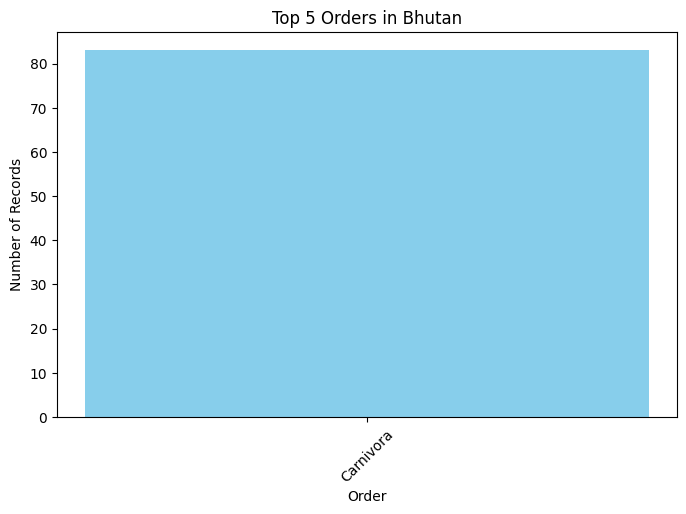

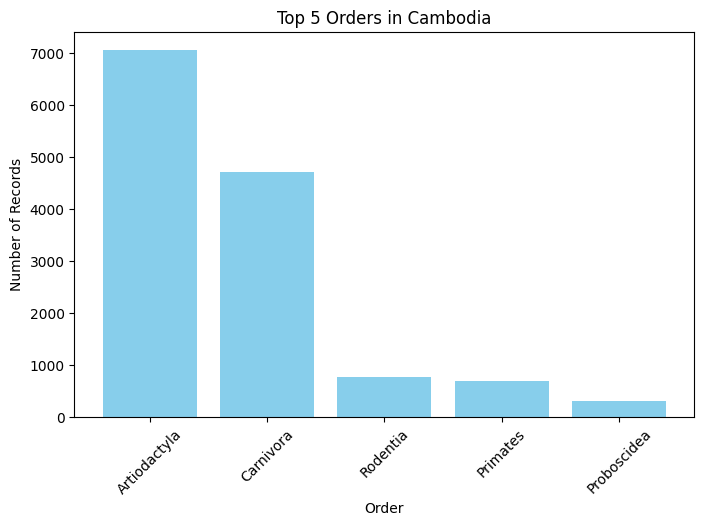

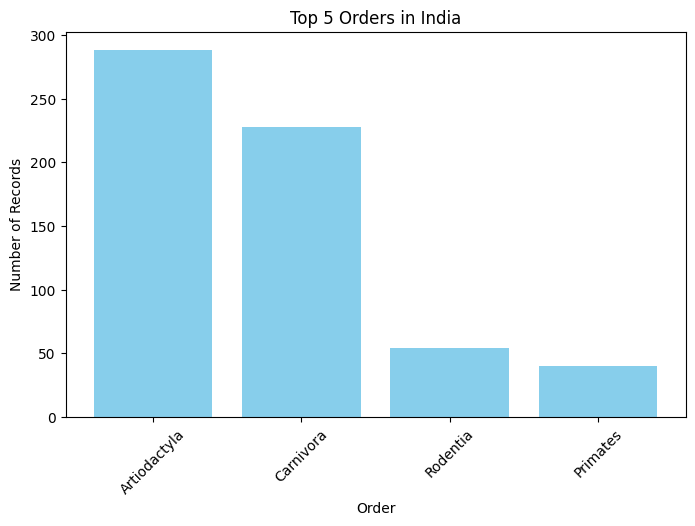

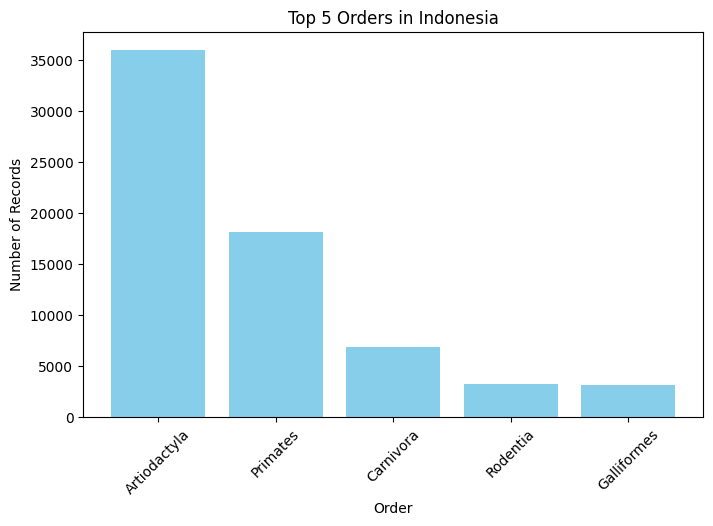

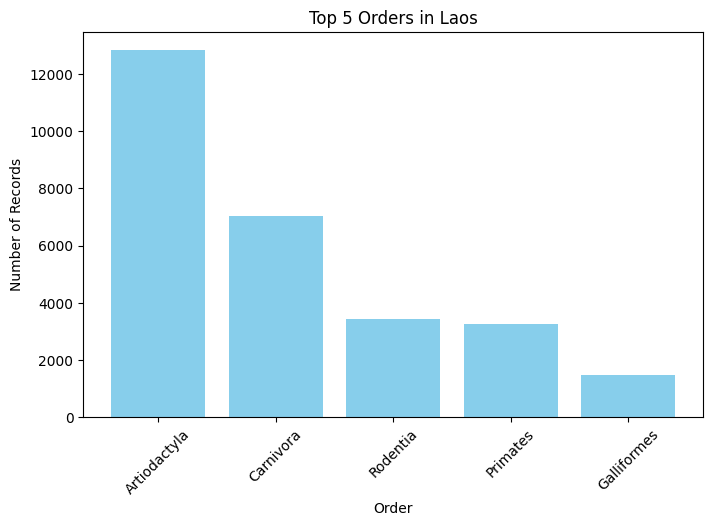

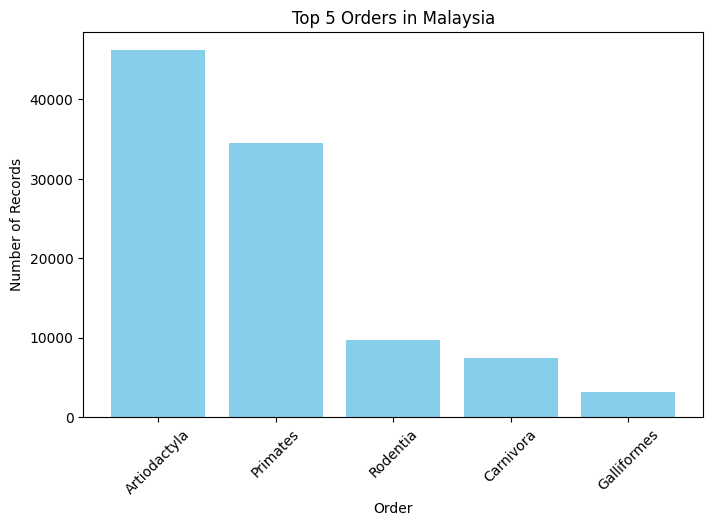

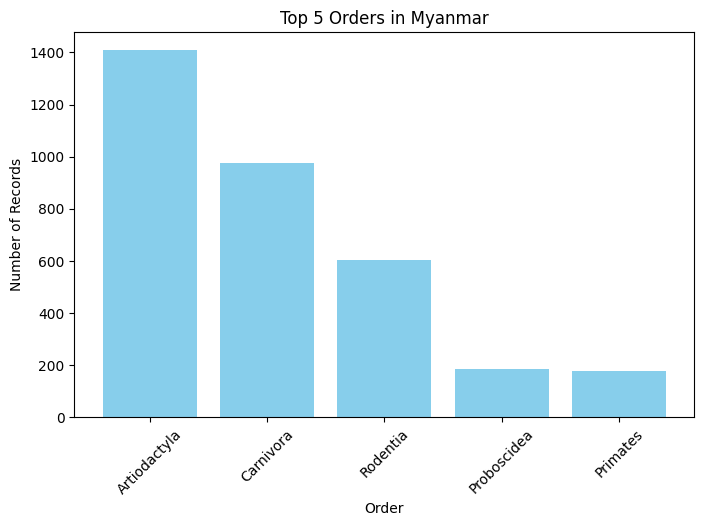

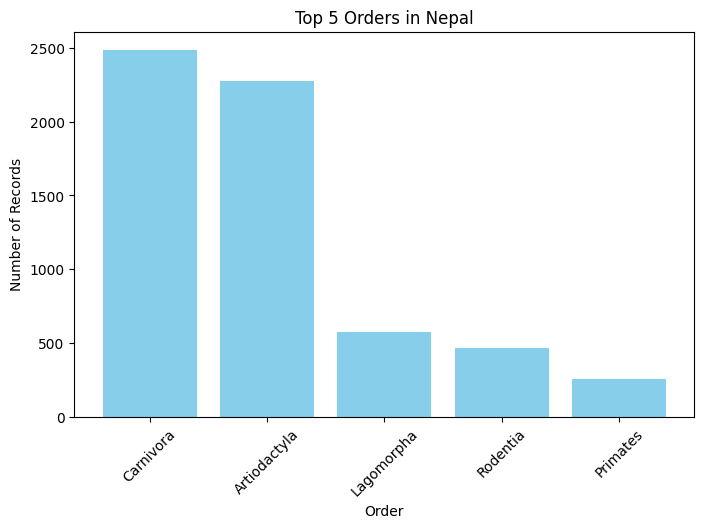

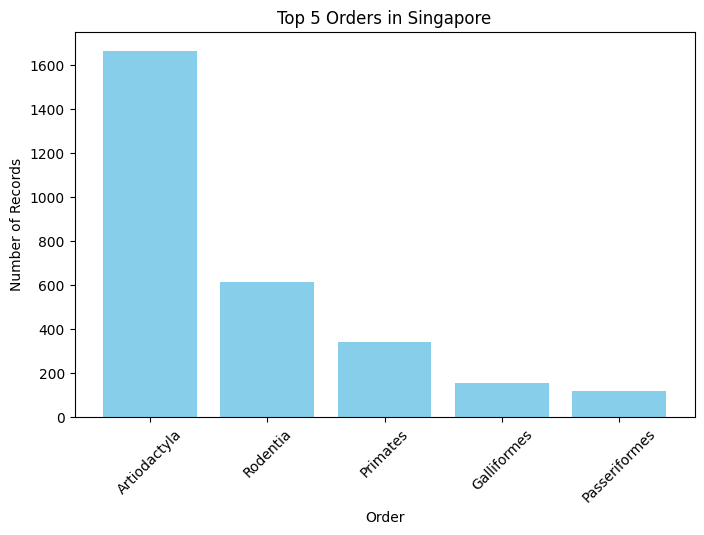

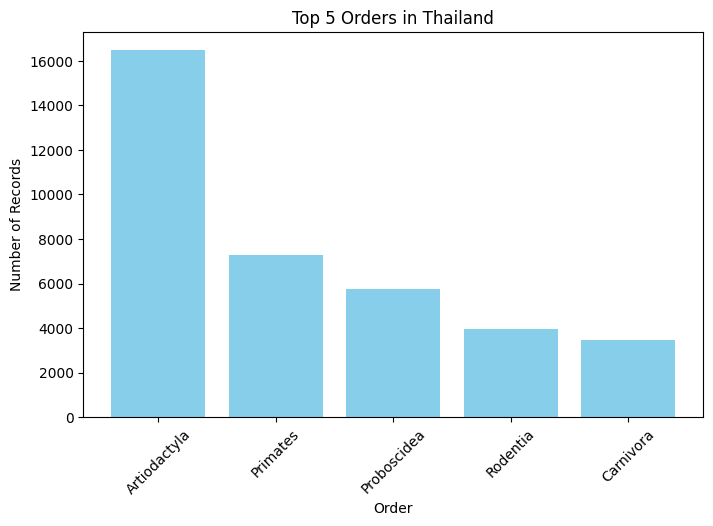

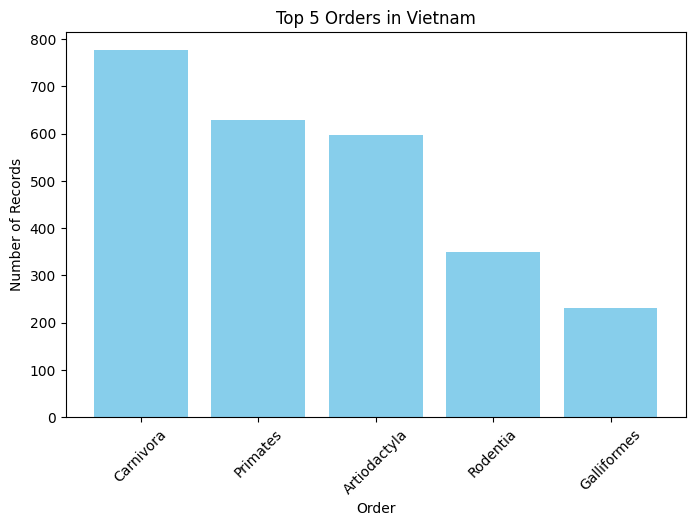

In [ ]:
# Filter dataset to include only wild animals
wild_df = df[df['domestic'] == 'wild']

# Display first few rows to verify
display(wild_df.head())
# Create a contingency table: country vs taxonomic order
contingency_table = pd.crosstab(wild_df['country'], wild_df['order'])
display(contingency_table)
# Chi-square test of independence
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

# Display expected frequencies as DataFrame
expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
display(expected_df)
# Visualization: Top 5 orders per country
import matplotlib.pyplot as plt

# Aggregate record counts by country and order
top_orders = wild_df.groupby(['country','order'])['records'].sum().reset_index()

# Sort orders within each country
top_orders_sorted = top_orders.sort_values(['country','records'], ascending=[True, False])

# Plot top 5 orders for each country
for country in top_orders_sorted['country'].unique():
    subset = top_orders_sorted[top_orders_sorted['country'] == country].head(5)
    plt.figure(figsize=(8,5))
    plt.bar(subset['order'], subset['records'], color='skyblue')
    plt.title(f"Top 5 Orders in {country}")
    plt.xlabel("Order")
    plt.ylabel("Number of Records")
    plt.xticks(rotation=45)
    plt.show()

import os
import matplotlib.pyplot as plt

# plots directory
if not os.path.exists("plots"):
    os.makedirs("plots")
filename = f"plots/top5_orders_{country.lower().replace(' ', '_')}.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.close()


## Analysis Summary: Distribution of Animal Orders by Country

The Chi-square test results indicate that the distribution of taxonomic orders is **not independent of country**.  
This suggests that different countries exhibit distinct compositions of animal types.

- The contingency table shows variations in order frequencies across countries.  
- Bar chart visualizations confirm that dominant orders differ by country (e.g., Carnivora and Artiodactyla are common, but their relative abundances vary).  
- These patterns reflect **geographically structured biodiversity**, influenced by habitat type, ecological conditions, and regional biogeography.  

**Note:** Observed differences may also be affected by **uneven sampling effort**, so the variations represent recorded detections rather than absolute species abundance.

**Conclusion:** Countries show significantly different compositions of wild animal orders, consistent with ecological and biogeographic expectations.

## Spatiotemporal Scatter Plots

This analysis visualizes sampling effort in space and time:

1. **All species:** longitude vs latitude, color-coded by survey start year.  
2. **Panthera tigris (Tiger):** longitude vs latitude, point size scaled by number of records.

These plots help understand geographic distribution of surveys and highlight hotspots for a specific species.

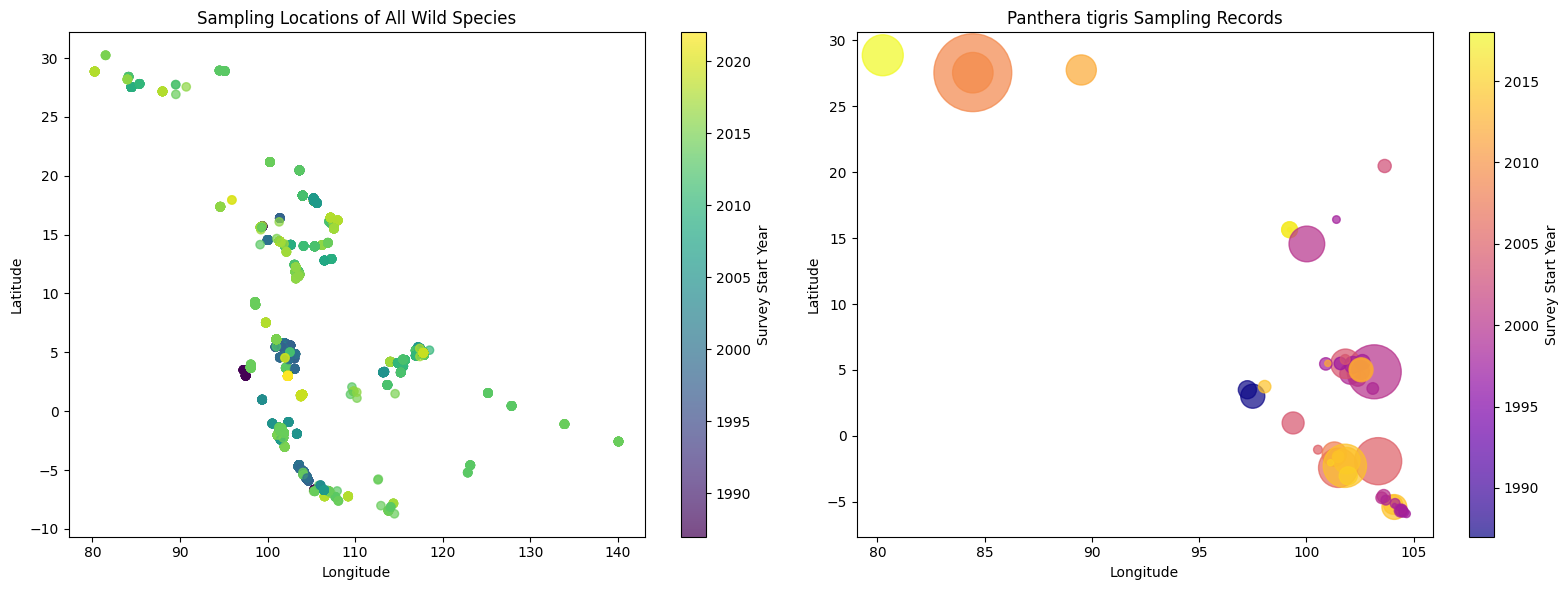

In [7]:
import matplotlib.pyplot as plt

# Create figure with two horizontally stacked subplots
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# ---- Scatter plot: all wild species ----
scatter_all = axes[0].scatter(
    wild_df['X_long'],
    wild_df['Y_lat'],
    c=wild_df['year_start'],
    cmap='viridis',
    alpha=0.7
)
axes[0].set_title("Sampling Locations of All Wild Species")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
plt.colorbar(scatter_all, ax=axes[0], label='Survey Start Year')

# ---- Scatter plot: Panthera tigris ----
tiger_df = wild_df[(wild_df['genus']=='Panthera') & (wild_df['species']=='tigris')]

scatter_tiger = axes[1].scatter(
    tiger_df['X_long'],
    tiger_df['Y_lat'],
    s=tiger_df['records']*10,  # scale by number of records
    c=tiger_df['year_start'],
    cmap='plasma',
    alpha=0.7
)
axes[1].set_title("Panthera tigris Sampling Records")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
plt.colorbar(scatter_tiger, ax=axes[1], label='Survey Start Year')

# Improve layout
plt.tight_layout()
plt.show()

import os
if not os.path.exists("plots"):
    os.makedirs("plots")
plt.savefig("plots/spatiotemporal_scatter.png", dpi=300, bbox_inches='tight')
plt.close()  

## Analysis of Spatial Clustering by Study Year

The spatiotemporal scatter plots reveal a clear pattern in the geographic distribution of studies over time:

- **Older studies (lighter colors):** These surveys tend to be clustered within a smaller number of locations and countries. This indicates that early camera-trap efforts were focused on a limited set of established study sites rather than being evenly distributed across the region.  

- **Newer studies (darker colors):** Recent surveys are more widely dispersed across both longitude and latitude. This suggests that sampling effort has expanded over time to cover a broader range of locations and countries.  

**Conclusion:** The visual evidence supports the interpretation that sampling coverage has increased over time. Early studies were geographically concentrated, while later efforts show greater regional dispersion, reflecting the gradual expansion of biodiversity monitoring in the study area.

## Diversity Metric Computation & Comparison

This analysis explores **survey site groupings based on the abundance of Carnivores and Primates**.  

We use **K-Means clustering** to partition sites into 4 clusters based on the counts of:

- **Carnivores (Carnivora)**  
- **Primates (Primates)**

The resulting clusters are visualized in a 2D scatter plot, with cluster membership indicated by color.

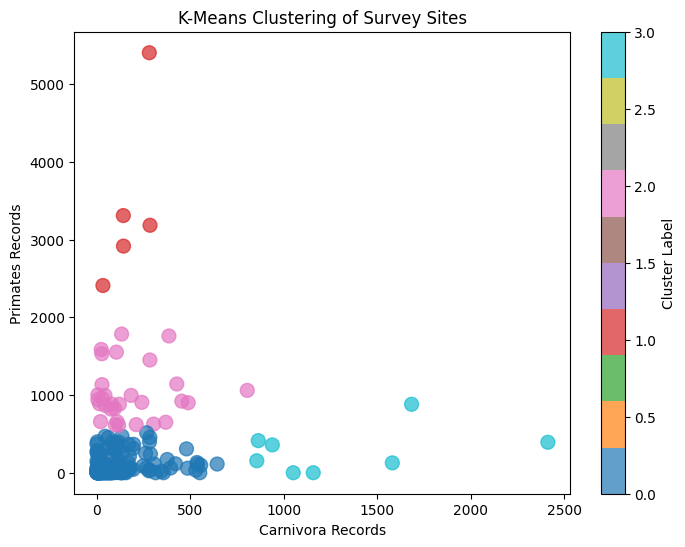

In [10]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ---- Data Preparation ----
wild_df = df[df['domestic']=='wild']

# Aggregate total records per survey_id
carnivore_records = wild_df[wild_df['order']=='Carnivora'].groupby('survey_id')['records'].sum()
primate_records = wild_df[wild_df['order']=='Primates'].groupby('survey_id')['records'].sum()

# Combine into a single DataFrame
df_cluster = pd.DataFrame({
    'Carnivora': carnivore_records,
    'Primates': primate_records
}).fillna(0)  # Replace missing values with 0

# ---- K-Means Modeling ----
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(df_cluster)

# Add cluster labels to DataFrame
df_cluster['Cluster'] = kmeans_labels

# ---- Visualization ----
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    df_cluster['Carnivora'],
    df_cluster['Primates'],
    c=df_cluster['Cluster'],
    cmap='tab10',
    s=100,
    alpha=0.7
)
plt.xlabel("Carnivora Records")
plt.ylabel("Primates Records")
plt.title("K-Means Clustering of Survey Sites")
plt.colorbar(scatter, label='Cluster Label')
plt.show()

if not os.path.exists("plots"):
    os.makedirs("plots")
plt.savefig("plots/kmeans_predator_primate.png", dpi=300, bbox_inches='tight')
plt.close()

## Interpretation of K-Means Clusters

The K-Means scatter plot identifies **four distinct clusters** of survey sites based on the relative abundance of Carnivores and Primates:

1. **Low Carnivore / Low Primate**  
   Sites in this cluster are close to the origin, indicating generally low detection rates for both groups. These may represent areas with limited survey effort or naturally low wildlife activity.  

2. **Low Carnivore / High Primate**  
   These sites have high primate counts but few carnivore records. Such patterns may correspond to habitats favouring primates (e.g., arboreal or forested areas) or areas where predators are less frequently detected.  

3. **High Carnivore / Low Primate**  
   Sites in this cluster exhibit high carnivore abundance with relatively few primates, suggesting locations where large terrestrial predators dominate, and primates are less common.  

4. **High Carnivore / High Primate**  
   These survey sites show high numbers for both groups, reflecting regions with high overall wildlife activity or particularly favourable ecological conditions supporting diverse mammal communities.  

**Conclusion:** The clustering highlights spatial heterogeneity in predator and primate abundance, illustrating differences in community composition across the study region.

## Diversity Metric Computation & Comparison

We calculate the **Shannon Diversity Index (H')** for each survey site based on species counts.  
The Shannon Index quantifies species diversity accounting for both abundance and evenness:

$$H' = -\sum (p_i \cdot \ln(p_i))$$

Where \(p_i\) is the proportion of species \(i\) in the survey.  

After computing the index for each survey, we compare diversity across three countries (Malaysia, Indonesia, Thailand) using the Kruskal-Wallis test, a non-parametric alternative to one-way ANOVA.

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import kruskal
# Filter dataset to include only wild animals
wild_data = data[data['domestic'] == 'wild']
# ---- Function to calculate Shannon Diversity Index ----
def calculate_shannon_index(counts):
    """
    Calculates the Shannon Diversity Index (H') for a single survey site.
    
    Args:
        counts (array-like): Counts of individuals per species at the site.
    
    Returns:
        float: Shannon Diversity Index.
    """
    counts = np.array(counts)
    total = counts.sum()
    if total == 0:
        return 0.0
    proportions = counts / total
    proportions = proportions[proportions > 0]  # Avoid log(0)
    return -np.sum(proportions * np.log(proportions))

# ---- Compute Shannon Index per survey ----
diversity_scores = []
for survey_id, group in wild_data.groupby('survey_id'):
    species_counts = group.groupby('species')['records'].sum().tolist()
    H = calculate_shannon_index(species_counts)
    diversity_scores.append({
        'survey_id': survey_id,
        'country': group['country'].iloc[0],
        'shannon_index': H
    })

df_diversity = pd.DataFrame(diversity_scores)
df_diversity.head()

# ---- Split diversity scores by country ----
malaysia_scores = df_diversity[df_diversity['country']=='Malaysia']['shannon_index'].tolist()
indonesia_scores = df_diversity[df_diversity['country']=='Indonesia']['shannon_index'].tolist()
thailand_scores = df_diversity[df_diversity['country']=='Thailand']['shannon_index'].tolist()

# ---- Kruskal-Wallis test (non-parametric ANOVA) ----
stat, p_value = kruskal(malaysia_scores, indonesia_scores, thailand_scores)

print(f"Kruskal-Wallis statistic: {stat:.3f}")
print(f"p-value: {p_value:.3f}")

if p_value < 0.05:
    print("Conclusion: Statistically significant differences in biodiversity among Malaysia, Indonesia, and Thailand.")
else:
    print("Conclusion: No statistically significant differences in biodiversity among Malaysia, Indonesia, and Thailand.")

Kruskal-Wallis statistic: 4.785
p-value: 0.091
Conclusion: No statistically significant differences in biodiversity among Malaysia, Indonesia, and Thailand.


A Kruskal-Wallis test was used to compare the mean Shannon diversity indices across the three countries: Malaysia, Indonesia, and Thailand. This non-parametric test is appropriate because it does not assume normality of the data and is suitable for comparing more than two independent groups.

The test results indicate that there is no statistically significant difference in mean biodiversity among the three countries. Specifically, the Kruskal-Wallis statistic was 4.785 with a p-value of 0.091. Since the p-value exceeds the 0.05 significance threshold, we fail to reject the null hypothesis. This suggests that any observed differences in biodiversity are likely due to random variation rather than true ecological differences between countries.

## Smooth Population Trends for Macaca nemestrina
Visualize trends in *Macaca nemestrina* detections over time. Steps:
- Aggregate records per year.
- Interpolate missing years using cubic smoothing.
- Plot original counts (scatter) and smoothed trend (line).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Step 1: Filter dataset to include only wild animals
wild_data = data[data['domestic'] == 'wild']

# Step 2: Select records for Macaca nemestrina (Pig-tailed macaque)
macaque_data = wild_data[(wild_data['genus'] == 'Macaca') & (wild_data['species'] == 'nemestrina')]

# Step 3: Aggregate annual detection counts
annual_records = macaque_data.groupby('year_start')['records'].sum().reset_index()
annual_records = annual_records.sort_values('year_start')  # ensure years are in ascending order

# Step 4: Prepare arrays for interpolation
x = annual_records['year_start'].values
y = annual_records['records'].values

# Step 5: Create cubic interpolation function to smooth trends
interp_func = interp1d(x, y, kind='cubic', fill_value="extrapolate")

# Step 6: Generate dense range of years for smooth curve
x_dense = np.linspace(x.min(), x.max(), 500)
y_smooth = interp_func(x_dense)

# Step 7: Plot original data and cubic interpolation curve
plt.figure(figsize=(10,6))
plt.scatter(x, y, color='red', label='Observed Records', zorder=5)
plt.plot(x_dense, y_smooth, color='blue', label='Cubic Interpolation', zorder=4)
plt.title("Smoothed Population Trend for Macaca nemestrina")
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Observation — Smoothed Population Trend for *Macaca nemestrina*

The red scatter points represent the actual yearly records of *Macaca nemestrina*, while the blue line shows a cubic interpolation of these points to illustrate a smoothed population trend over time.

Observations from the plot:
- There is clear **fluctuation in the number of records** over the years, reflecting either variations in population activity or differences in sampling effort.
- A pronounced peak appears around **2014–2015**, indicating a year with particularly high detection counts.
- Earlier years (late 1980s to early 2000s) show relatively **low and sparse detection**, suggesting limited sampling or lower recorded activity.
- The cubic interpolation provides a **smooth representation of trends**, making it easier to visualize overall increases or decreases without being distracted by single-year variability.
- Some negative values in the smooth curve at the very early years are **mathematical artifacts** of cubic interpolation beyond observed data points and should be interpreted cautiously.

Overall, this visualization effectively highlights temporal patterns in *Macaca nemestrina* records, showing periods of high and low activity while smoothing out irregularities in annual sampling.

## Taxonomy Modelling using OOP

This section models a simplified biological classification system using Object-Oriented Programming (OOP).

The taxonomy hierarchy follows:
**Order → Family → Genus → Species**

To represent this structure, three classes are defined:

- `BiologicalNode`: A base class representing any taxonomic entity.
- `Species`: A subclass representing individual species with detection records.
- `TaxonomicGroup`: A subclass representing higher-level groups (e.g., Family, Genus) that can contain other nodes.

This design uses inheritance to reflect hierarchical relationships in biological classification.

In [ ]:


# Base class representing any biological entity
class BiologicalNode:
    def __init__(self, name):
        self.name = name  # Scientific name

    def __repr__(self):
        return f"{self.name}"


# Class representing a species with detection records
class Species(BiologicalNode):
    def __init__(self, name, records):
        super().__init__(name)
        self.records = records  # Number of detections

    def __repr__(self):
        return f"Species(name='{self.name}', records={self.records})"


# Class representing taxonomic groups (e.g., Order, Family, Genus)
class TaxonomicGroup(BiologicalNode):
    def __init__(self, name, rank):
        super().__init__(name)
        self.rank = rank
        self.children = []  # List of child nodes (groups or species)

    def add_child(self, node):
        """Add a child node (Species or another TaxonomicGroup)."""
        self.children.append(node)

    def __repr__(self):
        return f"{self.rank}('{self.name}')"

    def get_total_records(self):
        total = 0
        for child in self.children:
            if isinstance(child, Species):
                total += child.records
            elif isinstance(child, TaxonomicGroup):
                total += child.get_total_records()
        return total

In [ ]:
# Example usage

# Create a genus
genus_panthera = TaxonomicGroup("Panthera", "Genus")

# Create species instances
species_tiger = Species("Panthera tigris", 150)
species_leopard = Species("Panthera pardus", 80)

# Build hierarchy
genus_panthera.add_child(species_tiger)
genus_panthera.add_child(species_leopard)

# Display structure
print(genus_panthera)
print("Members:", genus_panthera.children)
print("Total records:", genus_panthera.get_total_records())

Genus('Panthera')
Members: [Species(name='Panthera tigris', records=150), Species(name='Panthera pardus', records=80)]
Total records: 230


## Polymorphism and Recursion   

To extend the taxonomy model, a unified method is introduced to compute detection counts across different node types.

- For a `Species`, the count corresponds to its recorded detections.
- For a `TaxonomicGroup`, the count is the sum of all detections from its child nodes.

This is implemented using:
- **Polymorphism**: each class defines its own `get_count()` method.
- **Recursion**: groups compute totals by calling `get_count()` on their children.

This approach allows consistent and scalable aggregation across hierarchical structures.

In [ ]:
class BiologicalNode:
    def __init__(self, name):
        self.name = name

    # Polymorphic method to be overridden
    def get_count(self):
        pass


class Species(BiologicalNode):
    def __init__(self, name, record):
        super().__init__(name)
        self.record = record

    # Return detection count for a species
    def get_count(self):
        return self.record


class TaxonomicGroup(BiologicalNode):
    def __init__(self, name, ranking):
        super().__init__(name)
        self.ranking = ranking
        self.children = []

    # Add a child node
    def add_child(self, node):
        self.children.append(node)

    # Recursively sum counts
    def get_count(self):
        total = 0
        for child in self.children:
            total += child.get_count()
        return total

In [ ]:
# Example usage and validation

order_carnivora = TaxonomicGroup("Carnivora", "Order")

felidae = TaxonomicGroup("Felidae", "Family")
canidae = TaxonomicGroup("Canidae", "Family")

panthera = TaxonomicGroup("Panthera", "Genus")
canis = TaxonomicGroup("Canis", "Genus")

tiger = Species("Panthera tigris", 150)
leopard = Species("Panthera pardus", 80)
wolf = Species("Canis lupus", 40)
jackal = Species("Canis aureus", 20)

# Build hierarchy
panthera.add_child(tiger)
panthera.add_child(leopard)

canis.add_child(wolf)
canis.add_child(jackal)

felidae.add_child(panthera)
canidae.add_child(canis)

order_carnivora.add_child(felidae)
order_carnivora.add_child(canidae)

# Verify results
print(f"Total detections for {panthera.name}: {panthera.get_count()}")
print(f"Total detections for {canis.name}: {canis.get_count()}")
print(f"Total detections for {order_carnivora.name}: {order_carnivora.get_count()}")

# Assertions
assert panthera.get_count() == 230
assert canis.get_count() == 60
assert order_carnivora.get_count() == 290

print("All counts verified successfully!")

Total detections for Panthera: 230
Total detections for Canis: 60
Total detections for Carnivora: 290
All counts verified successfully!


## Recursive Tree Visualization

To improve interpretability of the taxonomy structure, a recursive display method is implemented.

- Each node prints its information with indentation based on its level in the hierarchy.
- `Species` nodes display their name and detection counts.
- `TaxonomicGroup` nodes display their rank, name, and total detections.
- The method uses recursion to traverse and print the entire hierarchy.

This approach provides a clear, tree-like representation of biological relationships and detection data.

In [ ]:
class BiologicalNode:
    def __init__(self, name):
        self.name = name

    def get_count(self):
        # To be implemented by subclasses
        pass

    def display(self, level=0):
        # To be implemented by subclasses
        pass


class Species(BiologicalNode):
    def __init__(self, name, records):
        super().__init__(name)
        self.records = records

    def get_count(self):
        return self.records

    def display(self, level=0):
        indent = "    " * level
        print(f"{indent}- [Species] {self.name}: {self.records} records")


class TaxonomicGroup(BiologicalNode):
    def __init__(self, name, rank):
        super().__init__(name)
        self.rank = rank
        self.children = []

    def add_child(self, node):
        self.children.append(node)

    def get_count(self):
        total = 0
        for child in self.children:
            total += child.get_count()
        return total

    def display(self, level=0):
        indent = "    " * level
        total = self.get_count()

        print(f"{indent}> [{self.rank}] {self.name} (Total: {total})")

        for child in self.children:
            child.display(level + 1)

In [ ]:
# Example usage

order_carnivora = TaxonomicGroup("Carnivora", "Order")

family_cats = TaxonomicGroup("Felidae", "Family")
family_dogs = TaxonomicGroup("Canidae", "Family")

genus_panthera = TaxonomicGroup("Panthera", "Genus")
genus_panthera.add_child(Species("Panthera tigris", 150))
genus_panthera.add_child(Species("Panthera pardus", 80))

genus_canis = TaxonomicGroup("Canis", "Genus")
genus_canis.add_child(Species("Canis aureus", 40))

family_cats.add_child(genus_panthera)
family_dogs.add_child(genus_canis)

order_carnivora.add_child(family_cats)
order_carnivora.add_child(family_dogs)

# Display hierarchy
order_carnivora.display()

> [Order] Carnivora (Total: 270)
    > [Family] Felidae (Total: 230)
        > [Genus] Panthera (Total: 230)
            - [Species] Panthera tigris: 150 records
            - [Species] Panthera pardus: 80 records
    > [Family] Canidae (Total: 40)
        > [Genus] Canis (Total: 40)
            - [Species] Canis aureus: 40 records


## Project Conclusion

This project analyzed tropical forest wildlife biodiversity using camera-trap data across Southeast Asia. Key insights include:

- Geographic patterns: Animal orders are distributed differently by country, reflecting ecological and habitat variation.
- Temporal trends: Surveys expanded over time. Macaca nemestrina shows peaks around 2014–2015.
- Species clustering: Predator and primate abundances revealed site-specific community structures.
- Biodiversity metrics: Shannon Diversity Index comparisons suggest no significant differences across Malaysia, Indonesia and Thailand, likely influenced by sampling effort.
- Taxonomy modeling: Hierarchical OOP models with recursion effectively represent taxonomic relationships and aggregate detection counts.

Takeaway: The analysis highlights structured biodiversity patterns, spatial-temporal dynamics, and demonstrates scalable methods for ecological data visualization and taxonomic modeling.